# **Import libraries**

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import shap

import warnings
warnings.filterwarnings("ignore")

# **Load the data**

In [4]:
df = pd.read_csv("/content/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

# **Inspect the data**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [10]:
df.duplicated().sum()

np.int64(1081)

In [11]:
quality_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

quality_summary

,Missing Values,Unique Values
Time,0,124592
V1,0,275663
V2,0,275663
V3,0,275663
V4,0,275663
V5,0,275663
V6,0,275663
V7,0,275663
V8,0,275663
V9,0,275663


# **Understand the target**

In [12]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [13]:
class_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
)

class_percentage

,proportion
Class,
0,99.827251
1,0.172749


# **Visualize class imbalance**

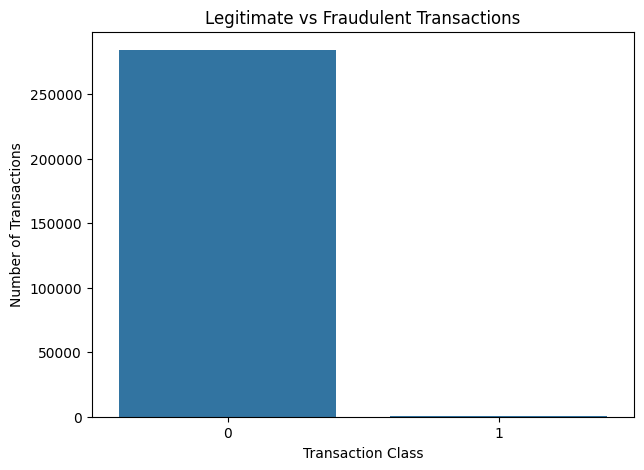

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

# **Analyze transaction amount**

In [15]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


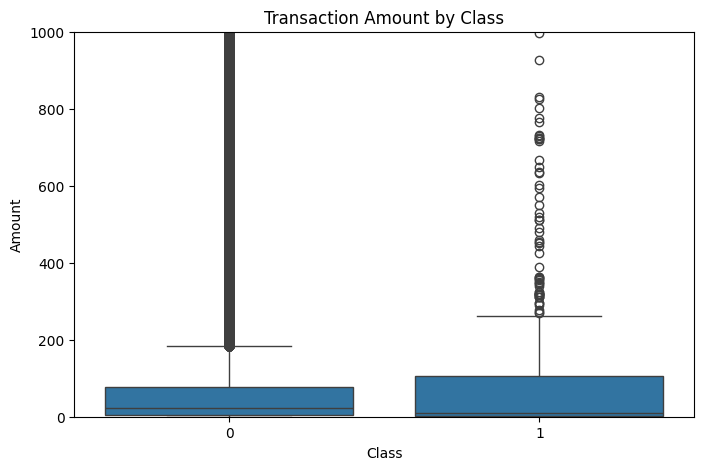

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.ylim(0, 1000)

plt.title("Transaction Amount by Class")

plt.show()

# **Analyze transaction time**

In [17]:
df["Time_hours"] = df["Time"] / 3600

In [18]:
df["Time_days"] = df["Time"] / (3600 * 24)

In [19]:
df["Hour"] = (
    (df["Time"] / 3600) % 24
)

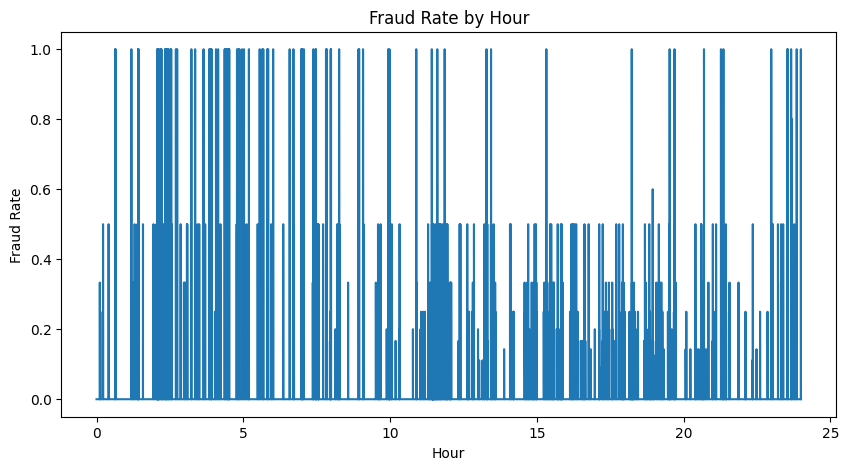

In [20]:
hour_fraud = (
    df.groupby("Hour")["Class"]
    .mean()
)

plt.figure(figsize=(10, 5))

hour_fraud.plot()

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")

plt.show()

# **Feature engineering**

In [21]:
df["Amount_log"] = np.log1p(df["Amount"])

In [22]:
df["Hour"]

,Hour
0,0.000000
1,0.000000
2,0.000278
3,0.000278
4,0.000556
...,...
284802,23.996111
284803,23.996389
284804,23.996667
284805,23.996667


In [23]:
df["Night"] = (
    (df["Hour"] < 6) |
    (df["Hour"] >= 22)
).astype(int)

# **Create amount-based features**

In [24]:
amount_median = df["Amount"].median()

In [25]:
df["Amount_to_Median"] = (
    df["Amount"] / (amount_median + 1e-6)
)

In [26]:
amount_95 = df["Amount"].quantile(0.95)

df["High_Amount"] = (
    df["Amount"] > amount_95
).astype(int)

# **Feature engineering with PCA variables**

In [27]:
v_columns = [f"V{i}" for i in range(1, 29)]

df["PCA_Magnitude"] = np.sqrt(
    (df[v_columns] ** 2).sum(axis=1)
)

In [28]:
df["PCA_Mean"] = df[v_columns].mean(axis=1)

df["PCA_Std"] = df[v_columns].std(axis=1)

df["PCA_Max"] = df[v_columns].max(axis=1)

df["PCA_Min"] = df[v_columns].min(axis=1)

# **Check your engineered features**

In [29]:
engineered_features = [
    "Amount_log",
    "Hour",
    "Night",
    "Amount_to_Median",
    "High_Amount",
    "PCA_Magnitude",
    "PCA_Mean",
    "PCA_Std",
    "PCA_Max",
    "PCA_Min"
]

df[engineered_features].describe()

,Amount_log,Hour,Night,Amount_to_Median,High_Amount,PCA_Magnitude,PCA_Mean,PCA_Std,PCA_Max,PCA_Min
count,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,2.848070e+05,284807.000000,284807.000000,284807.000000
mean,3.152188,14.537951,0.176656,4.015892,0.049971,4.780736,7.661099e-16,0.905772,2.117727,-2.050288
std,1.656648,5.847061,0.381378,11.369095,0.217885,2.806480,1.979868e-01,0.526441,1.234395,1.704709
min,0.000000,0.000000,0.000000,0.000000,0.000000,2.055632,-7.084104e+00,0.390182,0.396917,-113.743307
25%,1.887070,10.598194,0.000000,0.254545,0.000000,3.481321,-8.641028e-02,0.662418,1.429391,-2.319342
50%,3.135494,15.010833,0.000000,1.000000,0.000000,4.258678,1.755846e-02,0.808049,1.883552,-1.725235
75%,4.358822,19.329722,0.000000,3.507500,0.000000,5.275934,1.078486e-01,0.998900,2.309474,-1.261890
max,10.153941,23.999444,1.000000,1167.779947,1.000000,209.912539,8.018006e-01,40.275857,120.589494,-0.341359


# **SQL analysis**

In [31]:
import sqlite3

conn = sqlite3.connect("/content/transactions.db")

In [32]:
df.to_sql(
    "transactions",
    conn,
    if_exists="replace",
    index=False
)

284807

In [33]:
query = """
SELECT
    Class,
    COUNT(*) AS transaction_count,
    AVG(Amount) AS average_amount,
    MAX(Amount) AS maximum_amount
FROM transactions
GROUP BY Class;
"""

sql_result = pd.read_sql(query, conn)

sql_result

,Class,transaction_count,average_amount,maximum_amount
0,0,284315,88.291022,25691.16
1,1,492,122.211321,2125.87


**SQL fraud-rate analysis**

In [34]:
query = """
SELECT
    Hour,
    COUNT(*) AS total_transactions,
    SUM(Class) AS fraud_transactions,
    AVG(Class) AS fraud_rate
FROM transactions
GROUP BY Hour
ORDER BY Hour;
"""

hour_analysis = pd.read_sql(query, conn)

hour_analysis.head()

,Hour,total_transactions,fraud_transactions,fraud_rate
0,0.000000,3,0,0.0
1,0.000278,2,0,0.0
2,0.000278,4,0,0.0
3,0.000556,3,0,0.0
4,0.000556,2,0,0.0


# **Prepare the ML dataset**

In [35]:
features = (
    v_columns
    + [
        "Time",
        "Amount",
        "Amount_log",
        "Hour",
        "Night",
        "Amount_to_Median",
        "High_Amount",
        "PCA_Magnitude",
        "PCA_Mean",
        "PCA_Std",
        "PCA_Max",
        "PCA_Min"
    ]
)

In [36]:
X = df[features]

y = df["Class"]

# **Train/test split**

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print(
    "Fraud rate in training:",
    y_train.mean()
)

print(
    "Fraud rate in testing:",
    y_test.mean()
)

Training: (227845, 40)
Testing: (56962, 40)
Fraud rate in training: 0.001729245759178389
Fraud rate in testing: 0.0017204452090867595


# **Logistic Regression**

In [39]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [40]:
lr_probability = (
    logistic_model
    .predict_proba(X_test)[:, 1]
)

In [41]:
lr_prediction = (
    lr_probability >= 0.5
).astype(int)

# **Random Forest**

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [44]:
rf_probability = (
    rf_model
    .predict_proba(X_test)[:, 1]
)

rf_prediction = (
    rf_probability >= 0.5
).astype(int)

# **Gradient Boosting**

In [46]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [47]:
gb_probability = (
    gb_model
    .predict_proba(X_test)[:, 1]
)

gb_prediction = (
    gb_probability >= 0.5
).astype(int)

# **Evaluate correctly**

In [48]:
def evaluate_model(name, y_true, predictions, probabilities):

    return {
        "Model": name,
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "AUPRC": average_precision_score(
            y_true,
            probabilities
        )
    }

In [49]:
results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_prediction,
        lr_probability
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_prediction,
        rf_probability
    ),

    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_prediction,
        gb_probability
    )
])

results

,Model,Precision,Recall,F1,ROC_AUC,AUPRC
0,Logistic Regression,0.056005,0.918367,0.105572,0.973562,0.728414
1,Random Forest,0.818182,0.826531,0.822335,0.976266,0.814691
2,Gradient Boosting,0.772727,0.867347,0.817308,0.967031,0.674051


## **Precision-Recall curves**

In [50]:
lr_precision, lr_recall, _ = precision_recall_curve(
    y_test,
    lr_probability
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_probability
)

gb_precision, gb_recall, _ = precision_recall_curve(
    y_test,
    gb_probability
)

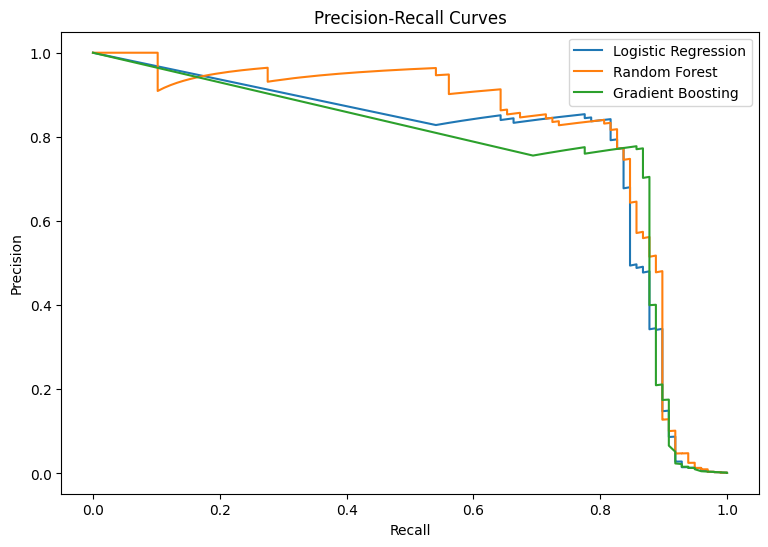

In [51]:
plt.figure(figsize=(9, 6))

plt.plot(
    lr_recall,
    lr_precision,
    label="Logistic Regression"
)

plt.plot(
    rf_recall,
    rf_precision,
    label="Random Forest"
)

plt.plot(
    gb_recall,
    gb_precision,
    label="Gradient Boosting"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curves")

plt.legend()

plt.show()

# **Confusion matrix**

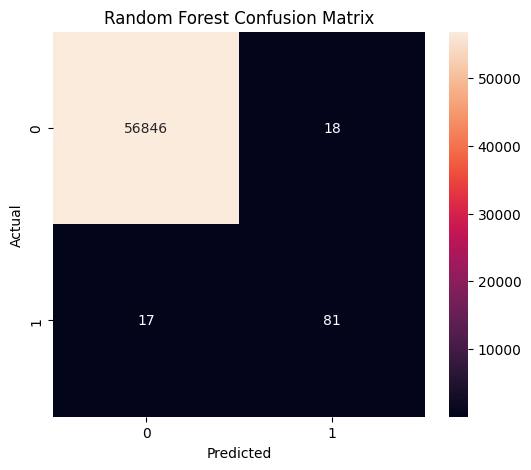

In [52]:
cm = confusion_matrix(
    y_test,
    rf_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

# **Feature importance**

In [53]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
13,V14,0.172347
37,PCA_Std,0.089563
35,PCA_Magnitude,0.085119
9,V10,0.081288
11,V12,0.068464
36,PCA_Mean,0.063938
39,PCA_Min,0.061126
3,V4,0.049612
16,V17,0.048381
10,V11,0.033812


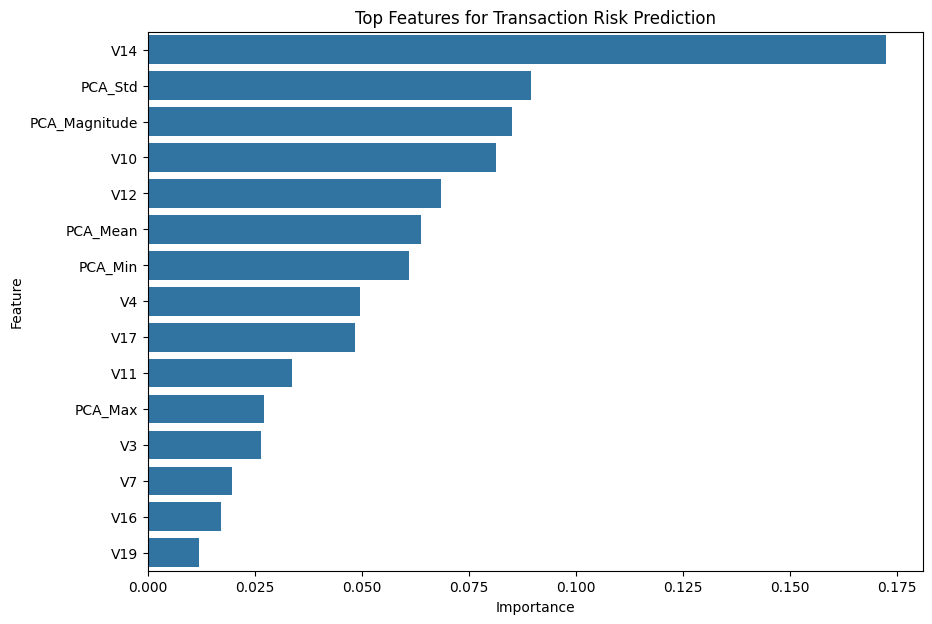

In [54]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features for Transaction Risk Prediction"
)

plt.show()

# **SHAP**

In [55]:
explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    X_test
)

In [56]:
type(shap_values)

numpy.ndarray

In [57]:
type(shap_values)

numpy.ndarray

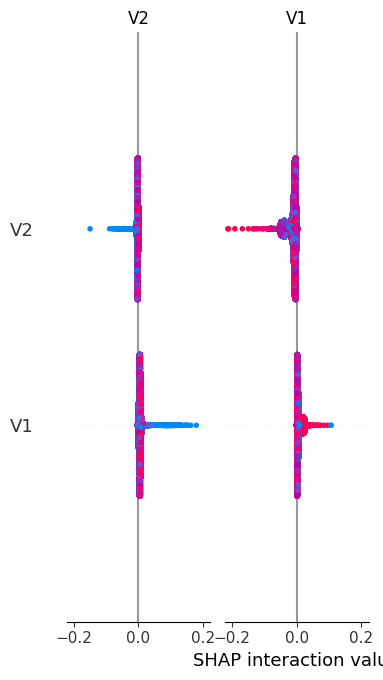

In [59]:
shap.summary_plot(
    shap_values,
    X_test
)

# **Create a risk score**

In [60]:
risk_score = rf_probability * 100

In [61]:
risk_results = X_test.copy()

risk_results["Actual_Class"] = y_test.values

risk_results["Risk_Score"] = risk_score

In [62]:
risk_results["Risk_Level"] = pd.cut(
    risk_results["Risk_Score"],
    bins=[0, 30, 70, 100],
    labels=[
        "Low",
        "Medium",
        "High"
    ],
    include_lowest=True
)

# **Create a transaction-risk visualization**

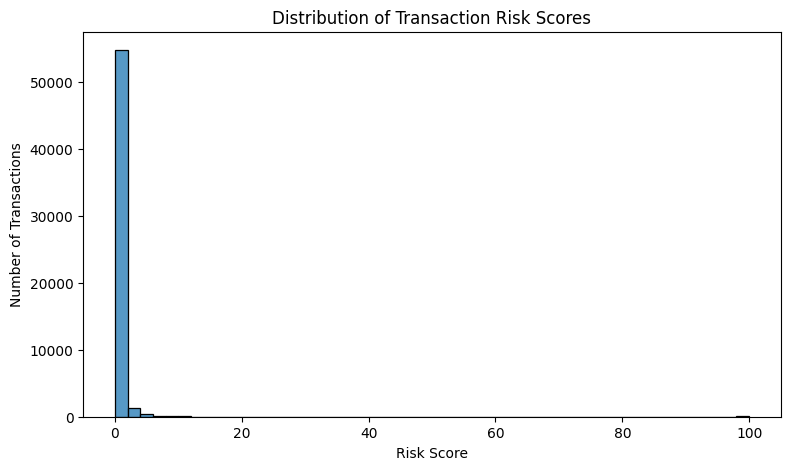

In [63]:
plt.figure(figsize=(9, 5))

sns.histplot(
    risk_results["Risk_Score"],
    bins=50
)

plt.xlabel("Risk Score")
plt.ylabel("Number of Transactions")

plt.title(
    "Distribution of Transaction Risk Scores"
)

plt.show()

# **Create a high-risk transaction table**

In [64]:
high_risk = (
    risk_results[
        risk_results["Risk_Level"] == "High"
    ]
    .sort_values(
        "Risk_Score",
        ascending=False
    )
)

high_risk.head(20)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,Amount_to_Median,High_Amount,PCA_Magnitude,PCA_Mean,PCA_Std,PCA_Max,PCA_Min,Actual_Class,Risk_Score,Risk_Level
42009,-2.740483,3.658095,-4.110636,5.340242,-2.666775,-0.092782,-4.388699,-0.280133,-2.821895,-4.466284,...,5.105909,0,20.319301,-1.424495,3.631431,5.340242,-8.815785,1,99.956438,High
150665,-6.750509,5.367416,-10.054635,9.064478,-7.968118,-2.263798,-10.317566,4.237666,-5.324109,-11.092392,...,9.529545,0,42.870872,-3.488444,7.446533,9.064478,-22.667905,1,99.955989,High
143336,-6.713407,3.921104,-9.746678,5.148263,-5.151563,-2.099389,-5.937767,3.578780,-4.684952,-8.537758,...,11.496363,0,28.228059,-2.182221,4.957168,6.348979,-11.939092,1,99.955936,High
251904,-1.040067,3.106703,-5.409027,3.109903,-0.887237,-2.497522,-2.073347,0.639818,-3.013331,-5.954838,...,4.310000,0,16.837257,-0.917557,3.102685,3.586395,-8.560423,1,99.955052,High
143333,-7.030308,3.421991,-9.525072,5.270891,-4.024630,-2.865682,-6.989195,3.791551,-4.622730,-8.409665,...,0.000000,0,28.205410,-2.202060,4.943275,6.309044,-11.887570,1,99.954720,High
15476,-21.209120,12.652197,-23.553933,6.174078,-16.026658,-4.422195,-16.229444,14.116002,-3.922741,-8.720245,...,4.545000,0,49.455452,-3.228786,8.931717,14.116002,-23.553933,1,99.954628,High
15539,-22.561699,13.208904,-24.643819,6.232532,-16.905611,-4.497439,-16.810184,14.955107,-3.871297,-8.581266,...,4.545000,0,51.151067,-3.271595,9.263106,14.955107,-24.643819,1,99.954628,High
15225,-19.856322,12.095893,-22.464083,6.115541,-15.148022,-4.346724,-15.648507,13.276805,-3.974162,-8.859194,...,4.545000,0,47.821602,-3.185991,8.612417,13.276805,-22.464083,1,99.954628,High
15810,-25.942434,14.601998,-27.368650,6.378395,-19.104033,-4.684806,-18.261393,17.052566,-3.742605,-8.233721,...,4.545000,0,55.622763,-3.378664,10.136588,17.052566,-27.368650,1,99.954628,High
141257,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,-8.099119,...,0.000000,0,27.263034,-1.886102,4.882571,7.182967,-12.991466,1,99.954349,High
